# Shape Detection Wasserstein all forms
by Eliot


## Load packages and scripts

In [46]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()

# --- Charger tes modules ---
include("src/preprocessing.jl")
include("src/filtration.jl")
include("src/persistence.jl")
include("src/visualization.jl")

using .Preprocessing
using .Filtration
using .Persistence
using .Visualization

using LinearAlgebra

  Activating project at `~/Slovenie/Topologie/Detecting-Shapes`
  0 dependencies successfully precompiled in 7 seconds. 306 already precompiled.

The following 1 direct dependency failed to precompile:

DetectingShapes 

Error: Missing source file for Base.PkgId(Base.UUID("d4c3e3b0-7a3f-4f2b-9a5c-0f2b7e6a1234"), "DetectingShapes"

In [47]:
# include src files 
include("src/filtration.jl")
import .Filtration
include("src/preprocessing.jl")
import .Preprocessing
include("src/visualization.jl")
import .Visualization
include("src/persistence.jl")
import .Persistence

In [3]:
path = "data/circle/samples/circle_0001.csv"

println("pwd() = ", pwd())
println("abspath(path) = ", abspath(path))
println("isfile(path) = ", isfile(path))

pwd() = /Users/eliotmorin/Slovenie/Topologie/Detecting-Shapes
abspath(path) = /Users/eliotmorin/Slovenie/Topologie/Detecting-Shapes/data/circle/samples/circle_0001.csv
isfile(path) = true


## We load the data

In [48]:

path = "data/circle/samples/circle_0001.csv"
shapes = ["circle", "line_segment", "disk", "ellipsoid","potato","sphere","torus"]
path_changes = Dict("line_segment" => "line")
n_pershape = [1, 2, 3, 4, 5, 6,7,8]
n_datapoints = 70

pointclouds = Vector{Any}()
corr_results = String[]

for s in shapes
    for i in n_pershape
        push!(corr_results, s)

        # construire le nom du fichier
        if haskey(path_changes, s)
            filename = string(path_changes[s], "_", lpad(i, 4, '0'), ".csv")
        else
            filename = string(s, "_", lpad(i, 4, '0'), ".csv")
        end

        # construire le chemin macOS
        path = joinpath("data", s, "samples", filename)
        println("Loading: ", path)

        df = Preprocessing.load_pointcloud_csv(path)
        df = df[1:n_datapoints, :]

        points = [tuple(df[j, :]...) for j in axes(df, 1)]
        push!(pointclouds, points)
    end
end

Loading: data/circle/samples/circle_0001.csv
Loading: data/circle/samples/circle_0002.csv
Loading: data/circle/samples/circle_0003.csv
Loading: data/circle/samples/circle_0004.csv
Loading: data/circle/samples/circle_0005.csv
Loading: data/circle/samples/circle_0006.csv
Loading: data/circle/samples/circle_0007.csv
Loading: data/circle/samples/circle_0008.csv
Loading: data/line_segment/samples/line_0001.csv
Loading: data/line_segment/samples/line_0002.csv
Loading: data/line_segment/samples/line_0003.csv
Loading: data/line_segment/samples/line_0004.csv
Loading: data/line_segment/samples/line_0005.csv
Loading: data/line_segment/samples/line_0006.csv
Loading: data/line_segment/samples/line_0007.csv
Loading: data/line_segment/samples/line_0008.csv
Loading: data/disk/samples/disk_0001.csv
Loading: data/disk/samples/disk_0002.csv
Loading: data/disk/samples/disk_0003.csv
Loading: data/disk/samples/disk_0004.csv
Loading: data/disk/samples/disk_0005.csv
Loading: data/disk/samples/disk_0006.csv
Lo

In [49]:

pointclouds_proc = Vector{Any}(undef, length(pointclouds))

for (k, S) in enumerate(pointclouds)

    P = reduce(vcat, [collect(p)' for p in S])

    P = Preprocessing.center_points(P)
    P = Preprocessing.normalize_scale(P) 

    pointclouds_proc[k] = [tuple(P[i,1], P[i,2], P[i,3]) for i in 1:size(P,1)]
end


## We Work on the filtration and persistence diagrams

In [50]:
diagrams = Persistence.create_persistence_diagram(pointclouds_proc, "Ripserer", true)


Create Wasserstein Matrix with the filtration_type Ripserer
n_pointclouds = 56
dim = 3
Compute homology of the pointcloud 1
result computed
Compute homology of the pointcloud 2
result computed
Compute homology of the pointcloud 3
result computed
Compute homology of the pointcloud 4
result computed
Compute homology of the pointcloud 5
result computed
Compute homology of the pointcloud 6
result computed
Compute homology of the pointcloud 7
result computed
Compute homology of the pointcloud 8
result computed
Compute homology of the pointcloud 9
result computed
Compute homology of the pointcloud 10
result computed
Compute homology of the pointcloud 11
result computed
Compute homology of the pointcloud 12
result computed
Compute homology of the pointcloud 13
result computed
Compute homology of the pointcloud 14
result computed
Compute homology of the pointcloud 15
result computed
Compute homology of the pointcloud 16
result computed
Compute homology of the pointcloud 17
result computed
Comp

56-element Vector{Any}:
 PersistenceDiagrams.PersistenceDiagram[70-element 0-dimensional PersistenceDiagram, 1-element 1-dimensional PersistenceDiagram, 6-element 2-dimensional PersistenceDiagram]
 PersistenceDiagrams.PersistenceDiagram[70-element 0-dimensional PersistenceDiagram, 1-element 1-dimensional PersistenceDiagram, 7-element 2-dimensional PersistenceDiagram]
 PersistenceDiagrams.PersistenceDiagram[70-element 0-dimensional PersistenceDiagram, 1-element 1-dimensional PersistenceDiagram, 9-element 2-dimensional PersistenceDiagram]
 PersistenceDiagrams.PersistenceDiagram[70-element 0-dimensional PersistenceDiagram, 1-element 1-dimensional PersistenceDiagram, 6-element 2-dimensional PersistenceDiagram]
 PersistenceDiagrams.PersistenceDiagram[70-element 0-dimensional PersistenceDiagram, 1-element 1-dimensional PersistenceDiagram, 6-element 2-dimensional PersistenceDiagram]
 PersistenceDiagrams.PersistenceDiagram[70-element 0-dimensional PersistenceDiagram, 1-element 1-dimensional Pe

In [51]:
@show length(diagrams)         # doit = nombre de nuages (ex: 20)
@show length(diagrams[1])      # en 3D: normalement 3 (H0,H1,H2)

length(diagrams) = 56
length(diagrams[1]) = 3


3

In [52]:
Ds = Persistence.create_wasserstein_matrix(diagrams)

3-element Vector{Matrix{Float64}}:
 [0.0 0.49530803571008825 … 4.165814021160696 4.7951462104286176; 0.49530803571008825 0.0 … 4.365264458163628 5.002176094270163; … ; 4.165814021160696 4.365264458163628 … 0.0 0.9202381839193327; 4.7951462104286176 5.002176094270163 … 0.9202381839193327 0.0]
 [0.0 0.07628807429412965 … 0.9140588281351723 1.0443184122331415; 0.07628807429412965 0.0 … 0.8377707538410426 0.9680303379390118; … ; 0.9140588281351723 0.8377707538410426 … 0.0 0.3783991565929805; 1.0443184122331415 0.9680303379390118 … 0.3783991565929805 0.0]
 [0.0 0.16092438472087944 … 0.1073013130406742 0.12945001458180183; 0.16092438472087944 0.0 … 0.08111764536363714 0.10326634690476477; … ; 0.1073013130406742 0.08111764536363714 … 0.0 0.049643275224559524; 0.12945001458180183 0.10326634690476477 … 0.049643275224559524 0.0]

In [53]:
using Plots

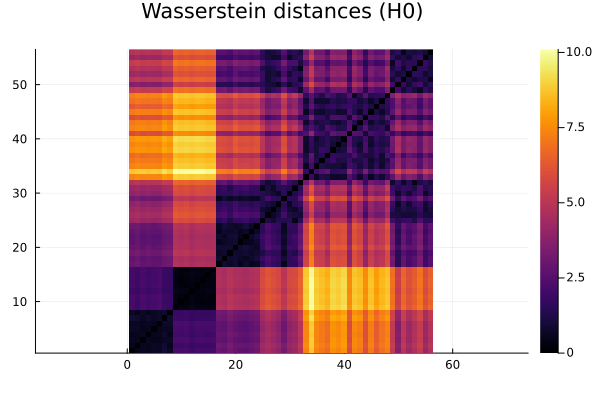

In [54]:
heatmap(Ds[1], aspect_ratio=:equal, title="Wasserstein distances (H0)")

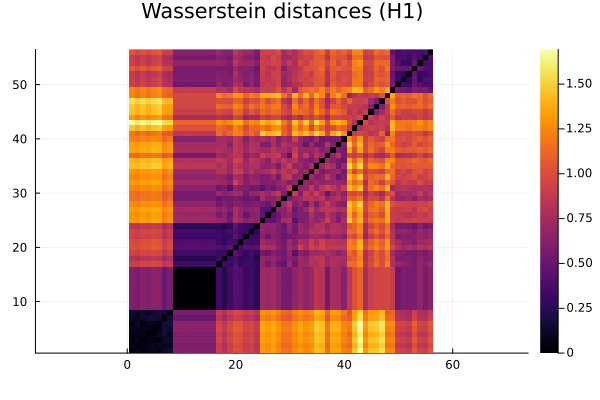

In [55]:
heatmap(Ds[2], aspect_ratio=:equal, title="Wasserstein distances (H1)")

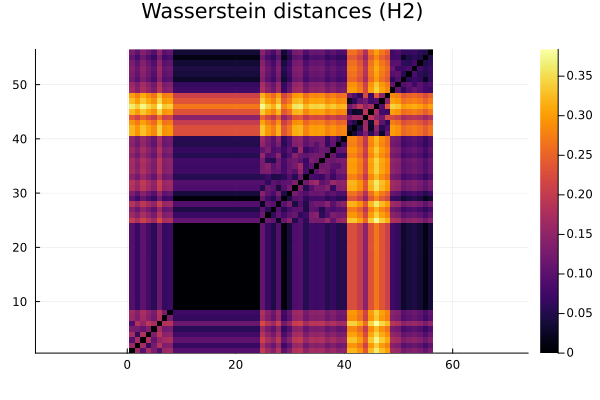

In [56]:
heatmap(Ds[3], aspect_ratio=:equal, title="Wasserstein distances (H2)")

In [58]:
corr_results


56-element Vector{String}:
 "circle"
 "circle"
 "circle"
 "circle"
 "circle"
 "circle"
 "circle"
 "circle"
 "line_segment"
 "line_segment"
 ⋮
 "sphere"
 "torus"
 "torus"
 "torus"
 "torus"
 "torus"
 "torus"
 "torus"
 "torus"

## We create cluster

In [59]:
using Clustering
using StatsPlots

results_clustering = []
for D in Ds
    rc = hclust(D; linkage=:average)   # D est NxN
    push!(results_clustering, rc)
end


In [60]:
clusters = []
for r in results_clustering
    push!(clusters, cutree(r; k = length(shapes)))  # k=4
end

In [61]:
for hi in 1:length(clusters)
    println("\nResults for H_", hi)
    for c in 1:length(shapes)
        println("Cluster $c ---------")
        println(corr_results[clusters[hi] .== c])
    end
end


Results for H_1
Cluster 1 ---------
["circle", "circle", "circle", "circle", "circle", "circle", "circle", "circle"]
Cluster 2 ---------
["line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment"]
Cluster 3 ---------
["disk", "disk", "disk", "disk", "disk", "disk", "disk", "disk", "ellipsoid"]
Cluster 4 ---------
["ellipsoid", "ellipsoid", "ellipsoid", "ellipsoid", "ellipsoid", "ellipsoid", "ellipsoid", "torus", "torus", "torus", "torus", "torus", "torus", "torus", "torus"]
Cluster 5 ---------
["potato", "potato", "potato", "potato", "potato", "potato", "potato", "sphere", "sphere", "sphere", "sphere", "sphere", "sphere"]
Cluster 6 ---------
["potato"]
Cluster 7 ---------
["sphere", "sphere"]

Results for H_2
Cluster 1 ---------
["circle", "circle", "circle", "circle", "circle", "circle", "circle", "circle"]
Cluster 2 ---------
["line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_seg

## We use KNN classification

In [ ]:

function combine_distances(Ds::Vector{<:AbstractMatrix}, weights::AbstractVector{<:Real})
    @assert length(Ds) == length(weights)
    n = size(Ds[1], 1)
    D = zeros(Float64, n, n)
    for (hi, w) in enumerate(weights)
        @assert size(Ds[hi], 1) == n && size(Ds[hi], 2) == n
        D .+= w .* Ds[hi]
    end
    return D
end

function knn_predict_index(D::AbstractMatrix, labels::Vector{String}, i::Int; k::Int=5)
    # elliot 
    n = size(D, 1)
    @assert length(labels) == n
    @assert 1 <= i <= n
    @assert k < n

    idxs = collect(1:n)
    deleteat!(idxs, i)            
    sorted = sort(idxs, by=j -> D[i,j])
    nn = sorted[1:k]

    counts = Dict{String, Int}()
    for j in nn
        counts[labels[j]] = get(counts, labels[j], 0) + 1
    end

    best_label = ""
    best_count = -1
    best_sumdist = Inf
    for (lab, c) in counts
        s = sum(D[i,j] for j in nn if labels[j] == lab)
        if (c > best_count) || (c == best_count && s < best_sumdist)
            best_label = lab
            best_count = c
            best_sumdist = s
        end
    end

    return best_label
end

function knn_leave_one_out(D::AbstractMatrix, labels::Vector{String}; k::Int=5)
    # elliot 
    n = size(D, 1)
    correct = 0
    errors = Tuple{Int,String,String}[]
    for i in 1:n
        pred = knn_predict_index(D, labels, i; k=k)
        if pred == labels[i]
            correct += 1
        else
            push!(errors, (i, labels[i], pred))
        end
    end
    return correct/n, errors
end


knn_leave_one_out (generic function with 1 method)

In [63]:
weights = [0.5, 3.0, 0.5]   # ajuste si besoin
Dcomb = combine_distances(Ds, weights)

56×56 Matrix{Float64}:
 0.0       0.55698   0.477549  …  5.64284  5.48513  4.87873  5.59525
 0.55698   0.0       0.553993     5.48797  5.34976  4.7365   5.45681
 0.477549  0.553993  0.0          5.60766  5.47535  4.8325   5.57081
 0.540583  0.471282  0.567229     5.44158  5.31034  4.69911  5.42615
 0.670864  0.613307  0.418669     5.58249  5.46394  4.81266  5.54985
 0.447546  0.697188  0.417697  …  5.72461  5.58158  4.94873  5.6852
 0.919975  0.76045   0.738706     5.45293  5.34404  4.66687  5.40696
 0.849624  0.533952  0.853695     5.34254  5.21178  4.60909  5.32331
 2.93523   2.71382   3.0232       4.99813  5.58053  4.743    5.25166
 2.91373   2.70285   3.00068      4.91552  5.49933  4.66928  5.16831
 ⋮                             ⋱                             ⋮
 7.47498   7.31672   7.53464      5.78047  5.12732  5.24504  5.45761
 6.46829   6.33375   6.45076      2.33462  2.01735  2.65023  2.06718
 4.69912   4.55129   4.65218      2.35353  2.34909  1.59901  1.94166
 5.31604   5.17491

In [ ]:
acc, errors = knn_leave_one_out(Dcomb, corr_results; k=5)
println("Accuracy = ", acc)
println("Nb errors = ", length(errors))
errors

LOO accuracy = 0.9642857142857143
Nb erreurs = 2


2-element Vector{Tuple{Int64, String, String}}:
 (29, "ellipsoid", "torus")
 (44, "sphere", "ellipsoid")

In [44]:
for k in (1,3,5,7,10)
    acc, _ = knn_leave_one_out(Dcomb, corr_results; k=k)
    println("k=$k -> acc=$acc")
end

k=1 -> acc=0.9642857142857143
k=3 -> acc=0.9642857142857143
k=5 -> acc=0.9642857142857143
k=7 -> acc=0.9642857142857143
k=10 -> acc=0.9642857142857143


In [64]:
# Analyze the errors in detail
println("\n=== ERROR ANALYSIS ===")
for (idx, true_label, pred_label) in errors
    println("Error #$idx:")
    println("  - True label: $true_label")
    println("  - Predicted: $pred_label")
    
    # Find which shape and which sample number
    shape_idx = div(idx-1, length(n_pershape)) + 1
    sample_idx = mod(idx-1, length(n_pershape)) + 1
    
    println("  - Shape: $(shapes[shape_idx])")
    println("  - Sample #: $(n_pershape[sample_idx])")
    println("  - Global position: $idx")
    println()
end



=== ERROR ANALYSIS ===
Error #29:
  - True label: ellipsoid
  - Predicted: torus
  - Shape: ellipsoid
  - Sample #: 5
  - Global position: 29

Error #44:
  - True label: sphere
  - Predicted: ellipsoid
  - Shape: sphere
  - Sample #: 4
  - Global position: 44

